In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Example of one subject, one electrode**

In [2]:
df = pd.read_csv("dataset/derivative_mid_5min/sub-001.csv")
df.head()

,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5,T6,Fz,Cz,Pz
0,28.106768,27.441973,23.673218,19.875109,18.152576,15.297676,18.360073,16.858160,15.213113,22.900726,23.686169,25.682659,22.683741,29.406986,16.644232,19.460236,19.185287,16.738230,17.906288
1,26.727509,26.027483,22.766195,18.799307,17.922928,14.887482,18.263588,17.043249,15.528177,23.191498,23.063129,25.104593,22.456659,28.306454,17.296949,19.315311,18.255154,16.482952,17.974981
2,25.426458,24.821260,21.670372,18.061966,17.749981,14.876583,18.253233,17.359100,15.895592,23.393311,22.509563,24.801735,22.091560,27.072908,17.793692,19.173122,17.506075,16.362591,18.104002
3,24.698235,24.245667,20.612814,17.946365,17.708075,15.343101,18.392147,17.848988,16.297136,23.588772,22.261555,24.921106,21.722656,26.061998,18.111496,19.207611,17.145636,16.513475,18.382906
4,24.880493,24.566380,19.826670,18.596111,17.852354,16.241646,18.706148,18.490246,16.699085,23.836700,22.469017,25.498295,21.471867,25.558849,18.246462,19.519907,17.319199,17.028008,18.853109


In [3]:
df.shape

(150000, 19)

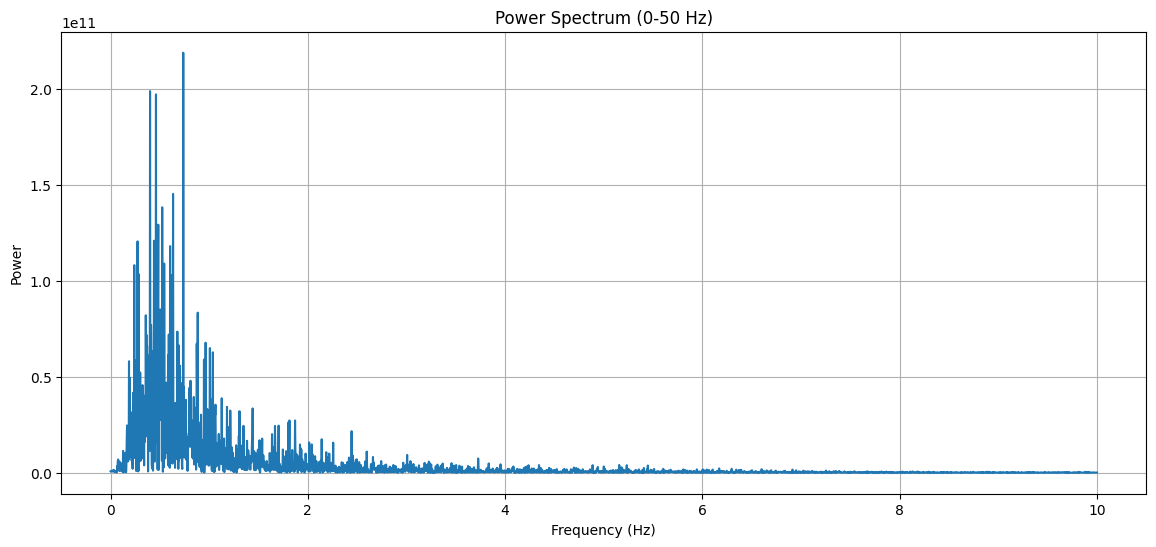

In [4]:
fft = np.fft.fft(df["Fp1"])
frequencies = np.fft.fftfreq(len(df["Fp1"]), 1/500)  # Frequency axis (Fs = 500 Hz)

max_index = np.argmax(frequencies > 10)

# Truncate arrays to include only 0-50 Hz
frequencies = frequencies[:max_index]
fft = fft[:max_index]

plt.figure(figsize=(14, 6))

plt.plot(frequencies, np.abs(fft)**2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectrum (0-50 Hz)")
plt.grid()
plt.show()


### below is single experimentation

In [5]:
df = pd.read_csv("dataset/derivative_mid_5min/sub-001.csv")

fft = np.fft.fft(df["Fp1"]) 
frequencies = np.fft.fftfreq(len(df["Fp1"]), 1/500)  # Frequency axis (Fs = 500 Hz)

power = np.abs(fft)**2

max_index = np.argmax(frequencies > 10) 

frequencies = frequencies[:max_index]
power = power[:max_index]
bins = np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.4, 2.8, 3.2, 3.6, 4.0, 9.0, 11.0])

freq_power = pd.DataFrame([frequencies, power]).T
freq_power.columns = ["Frequency", "Power"]
# Bin the frequency values
freq_power["Bin"] = pd.cut(freq_power["Frequency"], bins=bins, right=False)

binned_sums = freq_power.groupby("Bin", observed=False)["Power"].sum().reset_index()
binned_sums.columns = ["Bin", "PowerBand_subject001"]

# Drop the 4-9 Hz bin
binned_sums = binned_sums.drop(15)

electrode = "FP1"

# Format the bin column 
binned_sums["Electrode_Bin"] = binned_sums["Bin"].apply(lambda x: f"{electrode}_{x.left:.1f}-{x.right:.1f}")
# FP1_00_02 stands for the bin [0.0, 0.2), FP1_100_105 for [10.0, 10.5)

binned_sums = binned_sums[["Electrode_Bin", "PowerBand_subject001"]]

bins = binned_sums["Electrode_Bin"].to_numpy()
power_values = binned_sums["PowerBand_subject001"].to_numpy()

# Create a new DataFrame with bins as columns and power values as a single row
pd.DataFrame([power_values], columns=bins)

,FP1_0.0-0.2,FP1_0.2-0.4,FP1_0.4-0.6,FP1_0.6-0.8,FP1_0.8-1.0,FP1_1.0-1.2,FP1_1.2-1.4,FP1_1.4-1.6,FP1_1.6-1.8,FP1_1.8-2.0,FP1_2.0-2.4,FP1_2.4-2.8,FP1_2.8-3.2,FP1_3.2-3.6,FP1_3.6-4.0,FP1_9.0-11.0
0,3.529283e+11,1.890135e+12,2.513721e+12,1.730136e+12,1.068808e+12,8.165326e+11,4.503335e+11,3.920794e+11,2.797810e+11,3.512787e+11,3.680441e+11,2.562462e+11,1.786115e+11,1.425268e+11,1.247872e+11,3.190579e+10


## Feature Extraction

In [6]:
BINS = np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.4, 2.8, 3.2, 3.6, 4.0, 9.0, 11.0])

In [7]:
all_subjects_power_merged = pd.DataFrame()
for i in range(1, 89):
    subject_power_merged = pd.DataFrame()
    if i < 10:
        df = pd.read_csv(f"dataset/derivative_mid_5min/sub-00{i}.csv")
    else:
        df = pd.read_csv(f"dataset/derivative_mid_5min/sub-0{i}.csv")
    for electrode in df.columns:
        fft = np.fft.fft(df[electrode])
        power = np.abs(fft)**2
        frequencies = np.fft.fftfreq(len(df[electrode]), 1/500)  # Frequency axis (Fs = 500 Hz)
        max_index = np.argmax(frequencies > 10)  # First index exceeding 50 Hz
        frequencies = frequencies[:max_index]
        power = power[:max_index]

        freq_power = pd.DataFrame([frequencies, power]).T
        freq_power.columns = ["Frequency", "Power"]
        freq_power["Bin"] = pd.cut(freq_power["Frequency"], bins=BINS, right=False)

        # Sum the Power values (magnitude) within each bin
        binned_sums = freq_power.groupby("Bin", observed=False)["Power"].sum().reset_index()

        subject_id = f"subject_00{i}" if i < 10 else f"subject_0{i}"
        binned_sums.columns = ["Bin", subject_id]
        binned_sums = binned_sums.drop(15) # Drop the 4-9 Hz bin

        # Format the bin column, FP1_0.0-0.2 stands for the bin [0.0, 0.2), FP1_10.0-10.5 for [10.0, 10.5)
        binned_sums["Subject"] = binned_sums["Bin"].apply(lambda x: f"{electrode}_{x.left:.1f}-{x.right:.1f}")
        
        binned_sums = binned_sums[["Subject", subject_id]]# Drop the original Bin column

        bins = binned_sums["Subject"].to_numpy()
        power_values = binned_sums[subject_id].to_numpy()
        # a new DataFrame with bins as columns and power values as a single row
        subject_data = pd.DataFrame([power_values], columns=bins)

        subject_power_merged = pd.concat([subject_power_merged, subject_data], axis=1)
        
    all_subjects_power_merged = pd.concat([all_subjects_power_merged, subject_power_merged], axis=0)

In [8]:
all_subjects_power_merged.head()

,Fp1_0.0-0.2,Fp1_0.2-0.4,Fp1_0.4-0.6,Fp1_0.6-0.8,Fp1_0.8-1.0,Fp1_1.0-1.2,Fp1_1.2-1.4,Fp1_1.4-1.6,Fp1_1.6-1.8,Fp1_1.8-2.0,...,Pz_1.2-1.4,Pz_1.4-1.6,Pz_1.6-1.8,Pz_1.8-2.0,Pz_2.0-2.4,Pz_2.4-2.8,Pz_2.8-3.2,Pz_3.2-3.6,Pz_3.6-4.0,Pz_9.0-11.0
0,3.529283e+11,1.890135e+12,2.513721e+12,1.730136e+12,1.068808e+12,8.165326e+11,4.503335e+11,3.920794e+11,2.797810e+11,3.512787e+11,...,4.266079e+11,4.036235e+11,2.686985e+11,3.288197e+11,3.312854e+11,2.371525e+11,1.763504e+11,1.381950e+11,1.014901e+11,2.508040e+10
0,1.739217e+11,2.360292e+12,2.283920e+12,1.620654e+12,1.090091e+12,5.295506e+11,5.073476e+11,3.880522e+11,2.471657e+11,2.745762e+11,...,5.041474e+11,4.109034e+11,2.567097e+11,2.647269e+11,2.606394e+11,2.286672e+11,1.651087e+11,1.265555e+11,8.963591e+10,6.681001e+10
0,2.541523e+11,2.014221e+12,1.899600e+12,1.143379e+12,6.476780e+11,5.525213e+11,4.298715e+11,3.236251e+11,2.325881e+11,2.169912e+11,...,4.131174e+11,3.084780e+11,2.211164e+11,2.128428e+11,3.011666e+11,1.996318e+11,1.210466e+11,1.179676e+11,1.040777e+11,1.545886e+11
0,2.863454e+11,2.229562e+12,3.352909e+12,1.512736e+12,9.547159e+11,8.192087e+11,5.519779e+11,3.228617e+11,2.898284e+11,2.005609e+11,...,4.922463e+11,3.484089e+11,3.175769e+11,2.038796e+11,4.070591e+11,2.210771e+11,1.837638e+11,1.228429e+11,9.521807e+10,2.625049e+10
0,5.386780e+11,2.682647e+12,3.261899e+12,1.595648e+12,1.124836e+12,8.716807e+11,5.907919e+11,4.120885e+11,3.336682e+11,2.522586e+11,...,5.403737e+11,3.762848e+11,3.005664e+11,2.160235e+11,3.599922e+11,2.320431e+11,1.811274e+11,1.257000e+11,1.054855e+11,3.237314e+10


In [9]:
subject_ids = [f"subject_{i:03d}" for i in range(1, 89)] 
all_subjects_power_merged.index = subject_ids
all_subjects_power_merged.head()

,Fp1_0.0-0.2,Fp1_0.2-0.4,Fp1_0.4-0.6,Fp1_0.6-0.8,Fp1_0.8-1.0,Fp1_1.0-1.2,Fp1_1.2-1.4,Fp1_1.4-1.6,Fp1_1.6-1.8,Fp1_1.8-2.0,...,Pz_1.2-1.4,Pz_1.4-1.6,Pz_1.6-1.8,Pz_1.8-2.0,Pz_2.0-2.4,Pz_2.4-2.8,Pz_2.8-3.2,Pz_3.2-3.6,Pz_3.6-4.0,Pz_9.0-11.0
subject_001,3.529283e+11,1.890135e+12,2.513721e+12,1.730136e+12,1.068808e+12,8.165326e+11,4.503335e+11,3.920794e+11,2.797810e+11,3.512787e+11,...,4.266079e+11,4.036235e+11,2.686985e+11,3.288197e+11,3.312854e+11,2.371525e+11,1.763504e+11,1.381950e+11,1.014901e+11,2.508040e+10
subject_002,1.739217e+11,2.360292e+12,2.283920e+12,1.620654e+12,1.090091e+12,5.295506e+11,5.073476e+11,3.880522e+11,2.471657e+11,2.745762e+11,...,5.041474e+11,4.109034e+11,2.567097e+11,2.647269e+11,2.606394e+11,2.286672e+11,1.651087e+11,1.265555e+11,8.963591e+10,6.681001e+10
subject_003,2.541523e+11,2.014221e+12,1.899600e+12,1.143379e+12,6.476780e+11,5.525213e+11,4.298715e+11,3.236251e+11,2.325881e+11,2.169912e+11,...,4.131174e+11,3.084780e+11,2.211164e+11,2.128428e+11,3.011666e+11,1.996318e+11,1.210466e+11,1.179676e+11,1.040777e+11,1.545886e+11
subject_004,2.863454e+11,2.229562e+12,3.352909e+12,1.512736e+12,9.547159e+11,8.192087e+11,5.519779e+11,3.228617e+11,2.898284e+11,2.005609e+11,...,4.922463e+11,3.484089e+11,3.175769e+11,2.038796e+11,4.070591e+11,2.210771e+11,1.837638e+11,1.228429e+11,9.521807e+10,2.625049e+10
subject_005,5.386780e+11,2.682647e+12,3.261899e+12,1.595648e+12,1.124836e+12,8.716807e+11,5.907919e+11,4.120885e+11,3.336682e+11,2.522586e+11,...,5.403737e+11,3.762848e+11,3.005664e+11,2.160235e+11,3.599922e+11,2.320431e+11,1.811274e+11,1.257000e+11,1.054855e+11,3.237314e+10


In [11]:
all_subjects_power_merged.columns = pd.MultiIndex.from_tuples(
    [(col.split('_')[0], col.split('_')[1]) for col in all_subjects_power_merged.columns], 
    names=["Electrode", "Frequency Band"]
)

In [15]:
all_subjects_power_merged.head()

Electrode                Fp1                                            \
Frequency Band       0.0-0.2       0.2-0.4       0.4-0.6       0.6-0.8   
subject_001     3.529283e+11  1.890135e+12  2.513721e+12  1.730136e+12   
subject_002     1.739217e+11  2.360292e+12  2.283920e+12  1.620654e+12   
subject_003     2.541523e+11  2.014221e+12  1.899600e+12  1.143379e+12   
subject_004     2.863454e+11  2.229562e+12  3.352909e+12  1.512736e+12   
subject_005     5.386780e+11  2.682647e+12  3.261899e+12  1.595648e+12   

Electrode                                                               \
Frequency Band       0.8-1.0       1.0-1.2       1.2-1.4       1.4-1.6   
subject_001     1.068808e+12  8.165326e+11  4.503335e+11  3.920794e+11   
subject_002     1.090091e+12  5.295506e+11  5.073476e+11  3.880522e+11   
subject_003     6.476780e+11  5.525213e+11  4.298715e+11  3.236251e+11   
subject_004     9.547159e+11  8.192087e+11  5.519779e+11  3.228617e+11   
subject_005     1.124836e+12  8.716807e+11  5.907919e+11  4.120885e+11   

Electrode                                   ...            Pz                \
Frequency Band       1.6-1.8       1.8-2.0  ...       1.2-1.4       1.4-1.6   
subject_001     2.797810e+11  3.512787e+11  ...  4.266079e+11  4.036235e+11   
subject_002     2.471657e+11  2.745762e+11  ...  5.041474e+11  4.109034e+11   
subject_003     2.325881e+11  2.169912e+11  ...  4.131174e+11  3.084780e+11   
subject_004     2.898284e+11  2.005609e+11  ...  4.922463e+11  3.484089e+11   
subject_005     3.336682e+11  2.522586e+11  ...  5.403737e+11  3.762848e+11   

Electrode                                                               \
Frequency Band       1.6-1.8       1.8-2.0       2.0-2.4       2.4-2.8   
subject_001     2.686985e+11  3.288197e+11  3.312854e+11  2.371525e+11   
subject_002     2.567097e+11  2.647269e+11  2.606394e+11  2.286672e+11   
subject_003     2.211164e+11  2.128428e+11  3.011666e+11  1.996318e+11   
subject_004     3.175769e+11  2.038796e+11  4.070591e+11  2.210771e+11   
subject_005     3.005664e+11  2.160235e+11  3.599922e+11  2.320431e+11   

Electrode                                                               
Frequency Band       2.8-3.2       3.2-3.6       3.6-4.0      9.0-11.0  
subject_001     1.763504e+11  1.381950e+11  1.014901e+11  2.508040e+10  
subject_002     1.651087e+11  1.265555e+11  8.963591e+10  6.681001e+10  
subject_003     1.210466e+11  1.179676e+11  1.040777e+11  1.545886e+11  
subject_004     1.837638e+11  1.228429e+11  9.521807e+10  2.625049e+10  
subject_005     1.811274e+11  1.257000e+11  1.054855e+11  3.237314e+10  

[5 rows x 304 columns]

In [14]:
all_subjects_power_merged.to_csv("./dataset/PSDfeature.csv",index=True)